# 앙상블 모델 학습, 튜닝, 선정 및 시각화 파이프라인
본 노트북은 `modeling_basedon_EDA.ipynb`의 데이터를 기반으로, 여러 모델을 학습/튜닝하고 최적의 모델을 선정하여 앙상블하는 과정을 담고 있습니다.

In [ ]:
import sys
import subprocess
import importlib.util
if importlib.util.find_spec("shap") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "shap"])

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import shap

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    auc
)
import warnings
warnings.filterwarnings('ignore')

available_fonts = {font.name for font in fm.fontManager.ttflist}
if 'Malgun Gothic' in available_fonts:
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif 'AppleGothic' in available_fonts:
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False


## 1. 데이터 로드 및 전처리

In [ ]:
# 전처리가 완료된 데이터 로드
df = pd.read_csv("../../notebooks/01_data_collection/EDA/preprocessed_data/preprocessed.csv")

print("타깃 분포:")
print(df['is_churned'].value_counts())
print(f"이탈 비율: {df['is_churned'].mean():.2%}")


In [4]:
# .env 로드 및 DB 연결
from dotenv import load_dotenv
import sys
sys.path.append('.') # db_utils.py 경로 대응
import db_utils

load_dotenv("../../.env", override=True)
db_utils.test_connection()

query = """
    SELECT channel_identifier, youtube_channel_id as channel_id, channel_name    
    FROM channel_info_table cit
    """

channel_df = db_utils.run_query(query, display=False)

df = pd.merge(df, channel_df, on="channel_identifier", how="left")
print(f"Merge 후 데이터 형태: {df.shape}")


DB 연결 성공
host     : 127.0.0.1:3306
database : youtube_model_db
Merge 후 데이터 형태: (3331, 45)


In [5]:
ALL_FEATURES = ['subscriber_count', 'total_views', 'video_count',
       'channel_age_days', 'collected_video_count', 'avg_upload_interval_days',
       'std_upload_interval_days', 'max_gap_days', 'hiatus_count_30d',
       'avg_view_count', 'std_view_count', 'avg_like_count',
       'avg_comment_count', 'avg_normal_view', 'regularity_score', 'cv',
       'outlier_ratio', 'gap_ratio', 'sensitive_score', 'n_sensitive_videos',
       'sensitive_video_ratio', 'cat_politics', 'cat_hate', 'cat_aggro',
       'cat_adult_illegal', 'genre_BJ+연예인+인물', 'genre_IT+기술+컴퓨터',
       'genre_TV+방송', 'genre_가수+댄스+음악', 'genre_강의+교육', 'genre_게임',
       'genre_경제+부동산+주식', 'genre_국내+여행+해외', 'genre_라이프+취미', 'genre_레시피+요리+음식',
       'genre_만화+애니+영화', 'genre_미용+패션', 'genre_반려동물+애완', 'genre_스포츠+운동',
       'genre_어린이+키즈', 'genre_자동차']

X = df[ALL_FEATURES]
y = df['is_churned']

train_X, test_X, train_y, test_y = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train 크기: {train_X.shape}, Test 크기: {test_X.shape}")


Train 크기: (2664, 41), Test 크기: (667, 41)


## 2. 개별 모델 정의 및 하이퍼파라미터 튜닝
여러 모델을 생성하고 `RandomizedSearchCV`를 이용하여 최적의 파라미터를 찾습니다.

In [9]:
# 모델 초기화
models = {
    "XGBoost": XGBClassifier(random_state=42, eval_metric="logloss"),
    "LightGBM": LGBMClassifier(random_state=42, verbose=-1),
    "RandomForest": RandomForestClassifier(random_state=42),
    "GradientBoosting": GradientBoostingClassifier(random_state=42),
    "LogisticRegression": LogisticRegression(random_state=42, max_iter=1000)
}

# 튜닝할 파라미터 공간 정의
param_distributions = {
    "XGBoost": {
        "n_estimators": [100, 200, 300, 1000],
        "max_depth": [3, 5, 7],
        "learning_rate": [0.01, 0.05, 0.1, 0.03, 0.2]
    },
    "LightGBM": {
        "n_estimators": [100, 200, 300],
        "max_depth": [3, 5, 7, -1],
        "learning_rate": [0.01, 0.05, 0.1]
    },
    "RandomForest": {
        "n_estimators": [100, 200, 300],
        "max_depth": [5, 10, None],
        "min_samples_split": [2, 5, 10]
    },
    "GradientBoosting": {
        "n_estimators": [100, 200],
        "max_depth": [3, 5],
        "learning_rate": [0.01, 0.1]
    },
    "LogisticRegression": {
        "C": [0.1, 1.0, 10.0]
    }
}


In [10]:
best_estimators = {}
model_scores = {}

print("--- 모델 튜닝 시작 ---")
for name, model in models.items():
    print(f"[{name}] 튜닝 중...")
    # RandomizedSearchCV를 사용해 하이퍼파라미터 탐색
    search = RandomizedSearchCV(
        model, 
        param_distributions[name], 
        n_iter=10, 
        scoring='roc_auc', 
        cv=3, 
        random_state=42, 
        n_jobs=-1
    )
    # n_iter가 탐색 공간보다 클 경우를 대비하여 처리
    try:
        search.fit(train_X, train_y)
    except ValueError:
        # 공간이 작은 로지스틱 회귀 같은 경우 GridSearchCV 처럼 동작하게 n_iter 감소
        search = RandomizedSearchCV(
            model, 
            param_distributions[name], 
            n_iter=3, 
            scoring='roc_auc', 
            cv=3, 
            random_state=42, 
            n_jobs=-1
        )
        search.fit(train_X, train_y)

    best_estimators[name] = search.best_estimator_
    
    # 평가
    preds = search.predict(test_X)
    probs = search.predict_proba(test_X)[:, 1]
    acc = accuracy_score(test_y, preds)
    auc_val = roc_auc_score(test_y, probs)
    model_scores[name] = auc_val
    
    print(f"Best Params: {search.best_params_}")
    print(f"ROC-AUC: {auc_val:.4f} | Accuracy: {acc:.4f}\n")


--- 모델 튜닝 시작 ---
[XGBoost] 튜닝 중...
Best Params: {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.2}
ROC-AUC: 0.7746 | Accuracy: 0.8051

[LightGBM] 튜닝 중...
Best Params: {'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.05}
ROC-AUC: 0.7837 | Accuracy: 0.8036

[RandomForest] 튜닝 중...
Best Params: {'n_estimators': 300, 'min_samples_split': 2, 'max_depth': 10}
ROC-AUC: 0.7996 | Accuracy: 0.8096

[GradientBoosting] 튜닝 중...
Best Params: {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1}
ROC-AUC: 0.7856 | Accuracy: 0.8066

[LogisticRegression] 튜닝 중...


/Users/sj.kang/Desktop/project2/SKN30-2nd-1Team/.venv/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/sj.kang/Desktop/project2/SKN30-2nd-1Team/.venv/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://s

Best Params: {'C': 0.1}
ROC-AUC: 0.6740 | Accuracy: 0.7946



## 3. 베스트 모델 선정 및 앙상블
평가 결과(ROC-AUC)를 바탕으로 상위 3개 모델을 선정하고 Voting Classifier로 앙상블을 구축합니다.

In [11]:
# 상위 3개 모델 선정
top_models = sorted(model_scores.items(), key=lambda x: x[1], reverse=True)[:3]
print("--- 선정된 Top 3 모델 ---")
for idx, (name, score) in enumerate(top_models):
    print(f"{idx+1}. {name} (ROC-AUC: {score:.4f})")

# Top 모델로 앙상블 구성
ensemble_estimators = [(name, best_estimators[name]) for name, _ in top_models]

ensemble_model = VotingClassifier(
    estimators=ensemble_estimators,
    voting="soft"
)

ensemble_model.fit(train_X, train_y)


--- 선정된 Top 3 모델 ---
1. RandomForest (ROC-AUC: 0.7996)
2. GradientBoosting (ROC-AUC: 0.7856)
3. LightGBM (ROC-AUC: 0.7837)


VotingClassifier(estimators=[('RandomForest',
                              RandomForestClassifier(max_depth=10,
                                                     n_estimators=300,
                                                     random_state=42)),
                             ('GradientBoosting',
                              GradientBoostingClassifier(random_state=42)),
                             ('LightGBM',
                              LGBMClassifier(learning_rate=0.05, max_depth=5,
                                             n_estimators=200, random_state=42,
                                             verbose=-1))],
                 voting='soft')

In [12]:
# 앙상블 성능 평가
ens_preds = ensemble_model.predict(test_X)
ens_probs = ensemble_model.predict_proba(test_X)[:, 1]

ens_acc = accuracy_score(test_y, ens_preds)
ens_auc = roc_auc_score(test_y, ens_probs)

print("[앙상블 모델 최종 성능]")
print(f"Accuracy: {ens_acc:.4f}")
print(f"ROC-AUC: {ens_auc:.4f}")
print("\nClassification Report:\n", classification_report(test_y, ens_preds))


[앙상블 모델 최종 성능]
Accuracy: 0.8096
ROC-AUC: 0.7962

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.94      0.89       528
           1       0.58      0.32      0.41       139

    accuracy                           0.81       667
   macro avg       0.71      0.63      0.65       667
weighted avg       0.79      0.81      0.79       667



## 4. 평가 시각화 (그래프)

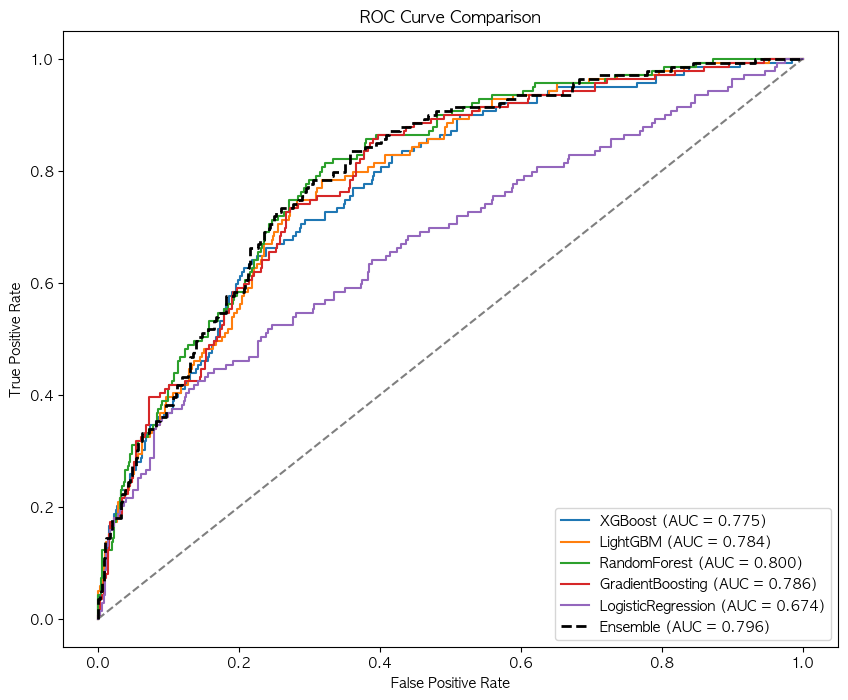

In [13]:
# 1) ROC Curve 비교
plt.figure(figsize=(10, 8))

for name, model in best_estimators.items():
    probs = model.predict_proba(test_X)[:, 1]
    fpr, tpr, _ = roc_curve(test_y, probs)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {model_scores[name]:.3f})")

# 앙상블 ROC Curve
ens_fpr, ens_tpr, _ = roc_curve(test_y, ens_probs)
plt.plot(ens_fpr, ens_tpr, label=f"Ensemble (AUC = {ens_auc:.3f})", color='black', linewidth=2, linestyle='--')

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc="lower right")
plt.show()


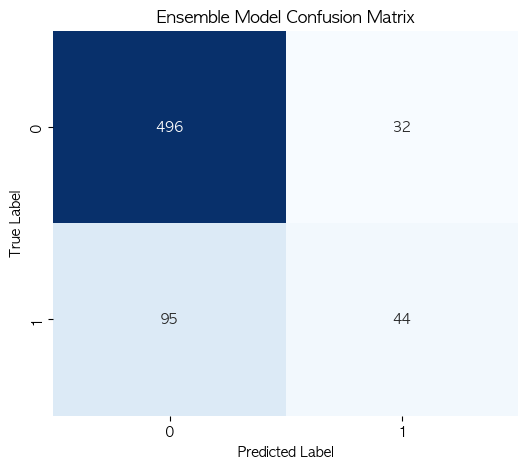

In [14]:
# 2) Confusion Matrix (Ensemble)
cm = confusion_matrix(test_y, ens_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Ensemble Model Confusion Matrix')
plt.show()


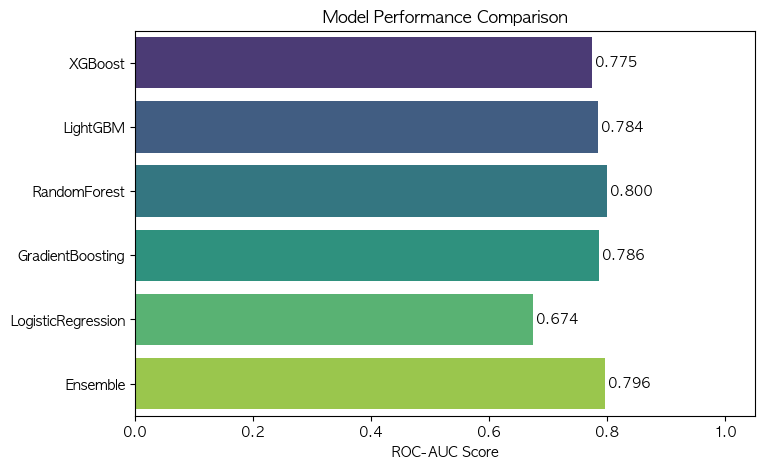

In [15]:
# 3) 모델 성능(ROC-AUC) 막대 그래프
plt.figure(figsize=(8, 5))
names = list(model_scores.keys()) + ['Ensemble']
scores = list(model_scores.values()) + [ens_auc]

sns.barplot(x=scores, y=names, palette='viridis')
for i, score in enumerate(scores):
    plt.text(score + 0.005, i, f"{score:.3f}", va='center')

plt.xlim(0, 1.05)
plt.xlabel('ROC-AUC Score')
plt.title('Model Performance Comparison')
plt.show()


## 5. SHAP 기반 Feature Importance 분석
트리 기반 베스트 모델(예: LightGBM 또는 XGBoost)을 활용하여 전반적인 피처 중요도를 시각화합니다.

'RandomForest' 모델 기반 SHAP 분석


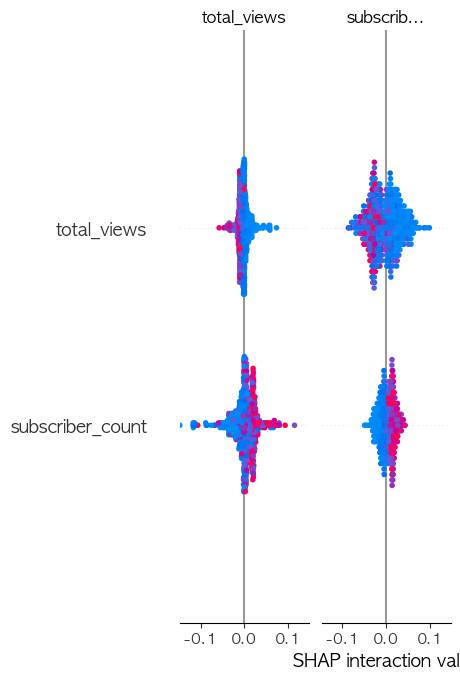

In [ ]:
# 앙상블의 SHAP을 직접 그리는 것은 복잡할 수 있으므로, 선정된 Top 1 모델을 기준으로 해석
top1_model_name = top_models[0][0]
top1_model = best_estimators[top1_model_name]

print(f"'{top1_model_name}' 모델 기반 SHAP 분석")
# 선형 모델일 경우 SHAP Explainer 방식이 다르므로 트리 모델이라 가정하고 TreeExplainer 사용 시도
try:
    explainer = shap.TreeExplainer(top1_model)
    shap_values_top1 = explainer(test_X)
    shap.summary_plot(shap_values_top1, test_X)
except:
    explainer = shap.Explainer(top1_model.predict, train_X)
    shap_values_top1 = explainer(test_X.iloc[:100])
    shap.summary_plot(shap_values_top1, test_X.iloc[:100])


# 학습된 모델저장

In [17]:
import joblib

joblib.dump(ensemble_model,"best_ensemble_model.pkl" )

['best_ensemble_model.pkl']